## Data Preparation Continued
- (Upload the cleaned csv's in this notebook)



In [232]:
!pip install matplotlib==3.10.6 \
numpy==2.3.3\
pandas==2.3.3 \
yfinance

In [233]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [234]:
#read main csv file
all_ipos = pd.read_csv("ipo_main_cleaned.csv", parse_dates=["Borsada İşlem Görme Tarihi"])

In [235]:
test = yf.download("PGSUS.IS", start="2013-04-26", progress=False)
print(test.head())
print(f"\nRows: {len(test)}")

/tmp/ipykernel_4032/319265524.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  test = yf.download("PGSUS.IS", start="2013-04-26", progress=False)


Price          Close      High       Low      Open    Volume
Ticker      PGSUS.IS  PGSUS.IS  PGSUS.IS  PGSUS.IS  PGSUS.IS
Date                                                        
2013-04-26  3.836239  3.918078  3.785089  3.836239  53690485
2013-07-23  5.872003  5.912923  5.626483  5.872003  15064793
2013-07-24  5.646943  5.974302  5.646943  5.646943   9709582
2013-07-25  5.646943  5.708323  5.503724  5.646943   8382052
2013-07-26  5.606023  5.708323  5.585564  5.606023   2447963

Rows: 3256


In [236]:
# Pull stock prices for all IPOs
failed_tickers = []
price_data = {}

for _, row in all_ipos.iterrows():
    ticker = row["Borsa Kodu"]
    listing_date = str(row["Borsada İşlem Görme Tarihi"])[:10]

    try:
        data = yf.download(f"{ticker}.IS", start=listing_date, progress=False)
        if len(data) > 0:
            price_data[ticker] = data
        else:
            failed_tickers.append(ticker)
    except:
        failed_tickers.append(ticker)

print(f"Success: {len(price_data)}")
print(f"Failed: {len(failed_tickers)}")
print(f"Failed tickers: {failed_tickers}")

/tmp/ipykernel_4032/1979011862.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(f"{ticker}.IS", start=listing_date, progress=False)
/tmp/ipykernel_4032/1979011862.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(f"{ticker}.IS", start=listing_date, progress=False)
/tmp/ipykernel_4032/1979011862.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(f"{ticker}.IS", start=listing_date, progress=False)
/tmp/ipykernel_4032/1979011862.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(f"{ticker}.IS", start=listing_date, progress=False)
/tmp/ipykernel_4032/1979011862.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(f"{ticker}.IS", start=listing_date, progress=False)
/tmp/ipykernel_4032/1979011862.py:10: FutureWarning: YF

Success: 244
Failed: 3
Failed tickers: ['AKPAZ', 'ARBUL', 'VIAGO']


In [237]:
# Pull BIST-100 index (from 2012 to calculate 200 day SMA) and USD/TRY
bist100 = yf.download("XU100.IS", start="2012-01-01", progress=False)
usdtry = yf.download("USDTRY=X", start="2012-01-01", progress=False)

print(f"BIST-100: {len(bist100)} days")
print(f"USD/TRY: {len(usdtry)} days")

/tmp/ipykernel_4032/106803598.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  bist100 = yf.download("XU100.IS", start="2012-01-01", progress=False)
/tmp/ipykernel_4032/106803598.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  usdtry = yf.download("USDTRY=X", start="2012-01-01", progress=False)


BIST-100: 3578 days
USD/TRY: 3718 days


### Calculate Stock Returns

In [238]:
from dateutil.relativedelta import relativedelta

horizons = {
    "1m": relativedelta(months=1),
    "3m": relativedelta(months=3),
    "6m": relativedelta(months=6),
    "12m": relativedelta(months=12),
    "24m": relativedelta(months=24),
    "60m": relativedelta(months=60),
}

returns = []

for _, row in all_ipos.iterrows():
    ticker = row["Borsa Kodu"]
    listing_date = row["Borsada İşlem Görme Tarihi"]

    if ticker not in price_data:
        continue

    prices = price_data[ticker]["Close"]

    if len(prices) == 0:
        continue

    first_price = prices.iloc[0].item()

    result = {"Borsa Kodu": ticker, "First_Close": first_price}

    for label, delta in horizons.items():
        target_date = listing_date + delta
        future = prices[prices.index >= str(target_date)]
        if len(future) > 0:
            future_price = future.iloc[0].item()
            result[f"return_{label}"] = (future_price - first_price) / first_price
        else:
            result[f"return_{label}"] = None

    returns.append(result)

returns_df = pd.DataFrame(returns)
print(f"Returns calculated for {len(returns_df)} IPOs")
print(returns_df[["Borsa Kodu", "return_1m", "return_12m"]].head(10))

Returns calculated for 244 IPOs
  Borsa Kodu  return_1m  return_12m
0      HLGYO   0.000000   -0.099619
1      SRVGY   0.000000   -0.103448
2      PGSUS   0.530667    0.456000
3      ROYAL  -0.078652   -0.148315
4       ODAS  -0.029762    0.019841
5      PAGYO  -0.076923   -0.094884
6      VERUS  -0.051095    0.189689
7      SANEL  -0.085492    0.462852
8      KRGYO  -0.172662   -0.237410
9      RTALB  -0.152190   -0.301992


### Calulate BIST100 Momentum

In [239]:
# Calculate BIST-100 200-day SMA and momentum at each IPO listing date
bist_close = bist100["Close"].squeeze()
bist_sma200 = bist_close.rolling(window=200).mean()

momentum = []

for _, row in all_ipos.iterrows():
    ticker = row["Borsa Kodu"]
    listing_date = str(row["Borsada İşlem Görme Tarihi"])[:10]

    sma = bist_sma200[bist_sma200.index <= listing_date]
    price = bist_close[bist_close.index <= listing_date]

    if len(sma) > 0 and len(price) > 0:
        sma_val = sma.iloc[-1].item()
        price_val = price.iloc[-1].item()
        pct_above = (price_val - sma_val) / sma_val
        momentum.append({"Borsa Kodu": ticker, "BIST100_SMA200_pct": pct_above, "BIST100_above_SMA200": price_val > sma_val})
    else:
        momentum.append({"Borsa Kodu": ticker, "BIST100_SMA200_pct": None, "BIST100_above_SMA200": None})

momentum_df = pd.DataFrame(momentum)
print(momentum_df.head(10))
print(f"\nIPOs in bull market: {momentum_df['BIST100_above_SMA200'].sum()}")
print(f"IPOs in bear market: {(~momentum_df['BIST100_above_SMA200']).sum()}")

  Borsa Kodu  BIST100_SMA200_pct  BIST100_above_SMA200
0      HLGYO            0.098822                  True
1      SRVGY            0.142170                  True
2      PGSUS            0.143228                  True
3      ROYAL            0.188861                  True
4       ODAS            0.190355                  True
5      PAGYO            0.188152                  True
6      AKPAZ            0.005237                  True
7      VERUS           -0.049321                 False
8      SANEL           -0.042926                 False
9      ARBUL            0.024709                  True

IPOs in bull market: 217
IPOs in bear market: 30


### Calulate 10% Gain Days

In [240]:
# Calculate tavan days (consecutive 10% daily gain from listing)
tavan_days = []

for _, row in all_ipos.iterrows():
    ticker = row["Borsa Kodu"]

    if ticker not in price_data:
        tavan_days.append({"Borsa Kodu": ticker, "tavan_days": None})
        continue

    prices = price_data[ticker]["Close"].squeeze()
    daily_returns = prices.pct_change()

    count = 0
    for ret in daily_returns.iloc[1:]:
        if ret >= 0.09:  # ~10% gain (using 9% to account for rounding)
            count += 1
        else:
            break

    tavan_days.append({"Borsa Kodu": ticker, "tavan_days": count})

tavan_df = pd.DataFrame(tavan_days)
print(tavan_df.describe())
print(f"\nTop 10 longest tavan:")
print(tavan_df.sort_values("tavan_days", ascending=False).head(10))

       tavan_days
count  244.000000
mean     3.196721
std      3.967231
min      0.000000
25%      0.000000
50%      2.000000
75%      6.000000
max     20.000000

Top 10 longest tavan:
    Borsa Kodu  tavan_days
51       TRILC        20.0
140      ONCSM        18.0
173      TARKM        14.0
167      OFSYM        14.0
196      PATEK        14.0
132      ALFAS        13.0
166      IZENR        13.0
168      TATEN        13.0
141      SDTTR        12.0
187       EKOS        12.0


In [241]:
# Calculate market cap at IPO
all_ipos["market_cap"] = all_ipos["Halka Arz Fiyatı (TL)"] * all_ipos["Yeni Sermaye (Bin TL)"] * 1000
print(all_ipos[["Borsa Kodu", "market_cap"]].head(10))

  Borsa Kodu    market_cap
0      HLGYO  8.943750e+08
1      SRVGY  1.419600e+08
2      PGSUS  1.881805e+09
3      ROYAL  2.670000e+08
4       ODAS  2.100000e+08
5      PAGYO  4.089000e+08
6      AKPAZ  1.198255e+08
7      VERUS  2.260000e+08
8      SANEL  4.577000e+07
9      ARBUL  5.400000e+07


In [242]:
# Merge all features together
final_df = all_ipos.merge(returns_df, on="Borsa Kodu", how="left")
final_df = final_df.merge(momentum_df, on="Borsa Kodu", how="left")
final_df = final_df.merge(tavan_df, on="Borsa Kodu", how="left")

print(f"Final dataset: {final_df.shape[0]} rows, {final_df.shape[1]} columns")
print(final_df.columns.tolist())

Final dataset: 247 rows, 29 columns
['Dönem', 'Borsa Kodu', 'Şirket Ünvanı', 'Halka Arz Şekli', 'Halka Arz Oranı (%)', 'Halka Arz Fiyatı (TL)', 'Ortak Satış Tutarı (Bin TL)', 'Nakit Sermaye Artırım Tutarı (Bin TL)', 'Satışa Hazır Bekletilen Pay Tutarı (Bin TL)', 'Satışa Sunulan Nominal Toplam Tutar (Bin TL)', 'Mevcut Sermaye (Bin TL)', 'Yeni Sermaye (Bin TL)', 'Satışa Sunulan Toplam Tutar (Piyasa Değeri Bin TL)', 'Satışa Sunulan Toplam Tutar (Piyasa Değeri Bin ABD Doları)', 'İlk İşlem Gördüğü Pazar', 'Halka Arza Aracılık Eden Kurum', 'Borsada İşlem Görme Tarihi', 'Sektör', 'market_cap', 'First_Close', 'return_1m', 'return_3m', 'return_6m', 'return_12m', 'return_24m', 'return_60m', 'BIST100_SMA200_pct', 'BIST100_above_SMA200', 'tavan_days']


### Remove Some Unnecessary Features

In [243]:
cols_keep = [
    "Borsa Kodu",
    "Şirket Ünvanı",
    "Borsada İşlem Görme Tarihi",
    "Halka Arz Oranı (%)",        # free float - hypothesis 1
    "Halka Arz Fiyatı (TL)",
    "Halka Arza Aracılık Eden Kurum",  # underwriter - hypothesis 2
    "Sektör",                      # GYO hypothesis - hypothesis 4
    "Yeni Sermaye (Bin TL)",
    "market_cap",                  # hypothesis 6
    "BIST100_SMA200_pct",
    "BIST100_above_SMA200",        # hypothesis 5
    "tavan_days",                  # hypothesis 7
    "return_1m", "return_3m", "return_6m",
    "return_12m", "return_24m", "return_60m",
]

final_df = final_df[cols_keep]
print(f"Final: {final_df.shape}")

Final: (247, 18)


In [244]:
# Calculate USD adjusted returns
from dateutil.relativedelta import relativedelta

usd_close = usdtry["Close"].squeeze()

def get_usd_rate(date_str):
    rate = usd_close[usd_close.index <= date_str]
    if len(rate) > 0:
        return rate.iloc[-1].item()
    return None

horizons = {
    "1m": relativedelta(months=1),
    "3m": relativedelta(months=3),
    "6m": relativedelta(months=6),
    "12m": relativedelta(months=12),
    "24m": relativedelta(months=24),
    "60m": relativedelta(months=60),
}

returns_usd = []

for _, row in all_ipos.iterrows():
    ticker = row["Borsa Kodu"]
    listing_date = row["Borsada İşlem Görme Tarihi"]

    if ticker not in price_data:
        continue

    prices = price_data[ticker]["Close"].squeeze()

    if len(prices) == 0:
        continue

    first_price_tl = prices.iloc[0].item()
    first_date = str(prices.index[0])[:10]
    first_usd = get_usd_rate(first_date)

    if first_usd is None:
        continue

    first_price_usd = first_price_tl / first_usd

    result = {"Borsa Kodu": ticker}

    for label, delta in horizons.items():
        target_date = listing_date + delta
        future = prices[prices.index >= str(target_date)]
        if len(future) > 0:
            future_price_tl = future.iloc[0].item()
            future_date = str(future.index[0])[:10]
            future_usd = get_usd_rate(future_date)
            if future_usd:
                future_price_usd = future_price_tl / future_usd
                result[f"return_{label}_usd"] = (future_price_usd - first_price_usd) / first_price_usd
            else:
                result[f"return_{label}_usd"] = None
        else:
            result[f"return_{label}_usd"] = None

    returns_usd.append(result)

returns_usd_df = pd.DataFrame(returns_usd)
print(f"USD returns calculated for {len(returns_usd_df)} IPOs")
print(returns_usd_df[["Borsa Kodu", "return_1m_usd", "return_12m_usd"]].head(10))

USD returns calculated for 244 IPOs
  Borsa Kodu  return_1m_usd  return_12m_usd
0      HLGYO      -0.008288       -0.254621
1      SRVGY       0.000000       -0.199160
2      PGSUS       0.440388        0.226235
3      ROYAL      -0.123953       -0.274175
4       ODAS      -0.078952       -0.111123
5      PAGYO      -0.119213       -0.196429
6      VERUS      -0.067240        0.082472
7      SANEL      -0.139803        0.334283
8      KRGYO      -0.171940       -0.408217
9      RTALB      -0.165197       -0.454413


In [245]:
# Merge the USD adjusted prices to the original file
final_df = final_df.merge(returns_usd_df, on="Borsa Kodu", how="left")
print(final_df.columns.tolist())

['Borsa Kodu', 'Şirket Ünvanı', 'Borsada İşlem Görme Tarihi', 'Halka Arz Oranı (%)', 'Halka Arz Fiyatı (TL)', 'Halka Arza Aracılık Eden Kurum', 'Sektör', 'Yeni Sermaye (Bin TL)', 'market_cap', 'BIST100_SMA200_pct', 'BIST100_above_SMA200', 'tavan_days', 'return_1m', 'return_3m', 'return_6m', 'return_12m', 'return_24m', 'return_60m', 'return_1m_usd', 'return_3m_usd', 'return_6m_usd', 'return_12m_usd', 'return_24m_usd', 'return_60m_usd']


In [246]:
# Market cap USD adjustement
final_df["usdtry_at_listing"] = final_df["Borsada İşlem Görme Tarihi"].apply(
    lambda d: get_usd_rate(str(d)[:10])
)
final_df["market_cap_usd"] = final_df["market_cap"] / final_df["usdtry_at_listing"]

In [247]:
# Save the processed csv
final_df.to_csv("ipo_final.csv", index=False)
print(f"Saved: {final_df.shape}")

Saved: (247, 26)


## Continue With Data Visualization and EDA

In [248]:
# Look into dataset to see any amomalies
ipo = pd.read_csv('ipo_final.csv', parse_dates=['Borsada İşlem Görme Tarihi'])
ipo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Borsa Kodu                      247 non-null    object        
 1   Şirket Ünvanı                   247 non-null    object        
 2   Borsada İşlem Görme Tarihi      247 non-null    datetime64[ns]
 3   Halka Arz Oranı (%)             247 non-null    float64       
 4   Halka Arz Fiyatı (TL)           247 non-null    float64       
 5   Halka Arza Aracılık Eden Kurum  247 non-null    object        
 6   Sektör                          247 non-null    object        
 7   Yeni Sermaye (Bin TL)           247 non-null    float64       
 8   market_cap                      247 non-null    float64       
 9   BIST100_SMA200_pct              247 non-null    float64       
 10  BIST100_above_SMA200            247 non-null    bool          
 11  tavan_

In [249]:
ipo.describe().T

,count,mean,min,25%,50%,75%,max,std
Borsada İşlem Görme Tarihi,247,2021-11-14 07:52:13.603238912,2013-02-22 00:00:00,2021-05-17 12:00:00,2022-06-17 00:00:00,2023-11-02 00:00:00,2025-12-18 00:00:00,NaN
Halka Arz Oranı (%),247.0,26.724939,0.0,20.83,25.04,30.625,74.75,8.597057
Halka Arz Fiyatı (TL),247.0,21.314494,1.1,7.215,14.0,25.0,135.0,24.131441
Yeni Sermaye (Bin TL),247.0,328677.315951,4500.0,50729.82,123750.0,270500.0,20000000.0,1325573.610907
market_cap,247.0,4521665541.42915,31000000.0,551285000.0,1906905000.0,5332960000.0,44685000000.0,7027467454.163303
BIST100_SMA200_pct,247.0,0.180569,-0.09025,0.040648,0.169636,0.265577,0.723793,0.1763
tavan_days,244.0,3.196721,0.0,0.0,2.0,6.0,20.0,3.967231
return_1m,244.0,0.42482,-0.383244,-0.050274,0.099712,0.577585,5.06599,0.843151
return_3m,244.0,0.612007,-0.430253,-0.01942,0.201502,0.735651,7.249351,1.18733
return_6m,240.0,0.921374,-0.462825,0.002005,0.4367,1.217137,10.268151,1.511997


In [250]:
# see how much is missing
ipo.isna().mean().sort_values(ascending=False).head(10)

,0
return_60m_usd,0.785425
return_60m,0.785425
return_24m,0.182186
return_24m_usd,0.182186
return_12m_usd,0.032389
return_12m,0.032389
return_6m,0.028340
return_6m_usd,0.028340
tavan_days,0.012146
return_1m_usd,0.012146


In [251]:
# extracts years for later use
ipo["Year"] = ipo["Borsada İşlem Görme Tarihi"].dt.year

### Start Visualization With Charts

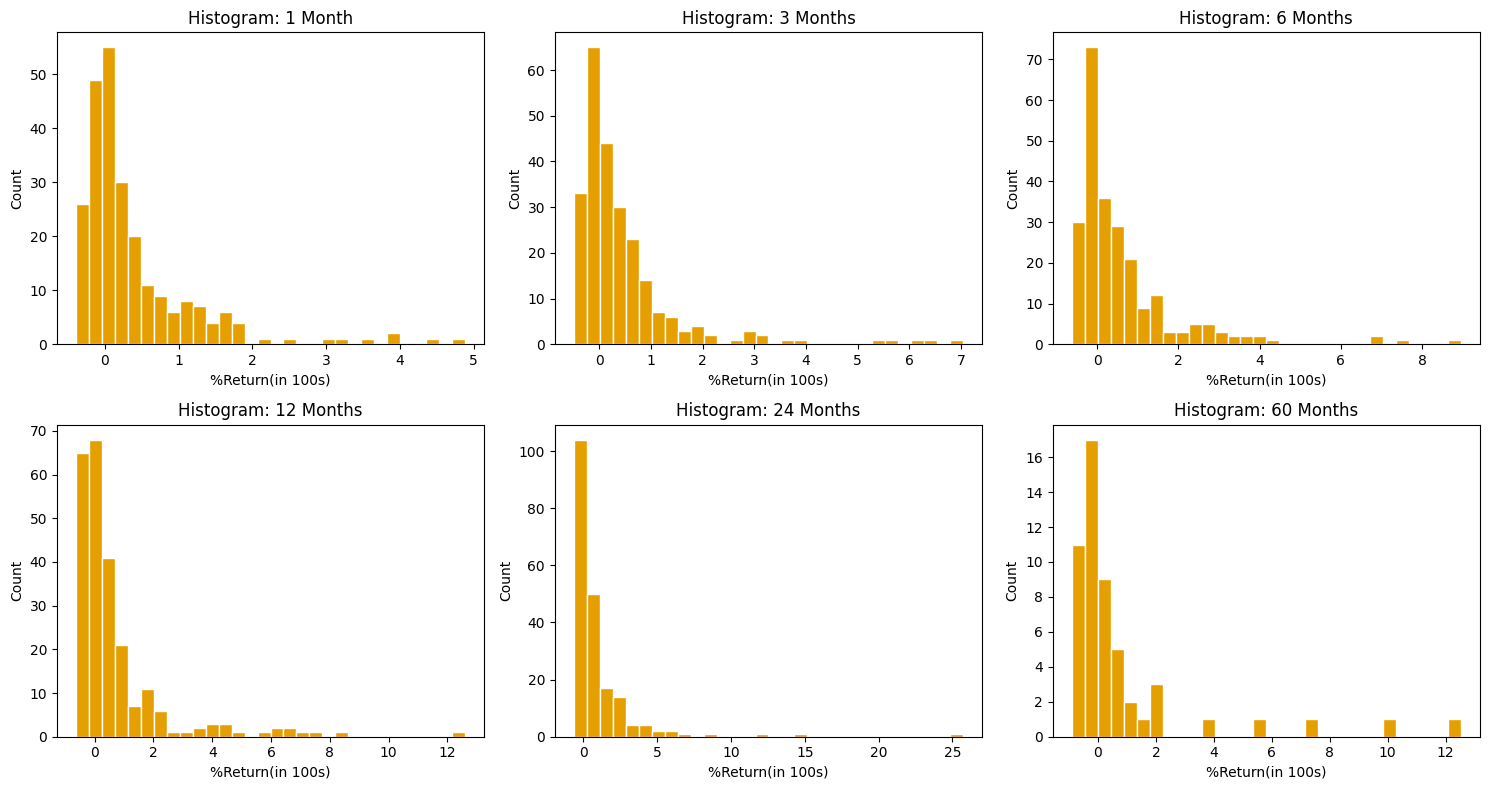

In [252]:
# IPO count by returns, on different time horizons
# Note that max loss is 100%, thats why its only right skewed
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

cols = ['return_1m_usd','return_3m_usd','return_6m_usd','return_12m_usd','return_24m_usd','return_60m_usd']
titles = ['1 Month','3 Months','6 Months','12 Months','24 Months','60 Months']

for i in range(6):
  axes[i].hist(ipo[cols[i]].dropna(), bins=30, color='#E69F00', edgecolor='white')
  axes[i].set_title(f'Histogram: {titles[i]}')
  axes[i].set_ylabel('Count')
  axes[i].set_xlabel('%Return(in 100s)')

fig.tight_layout()
plt.show()


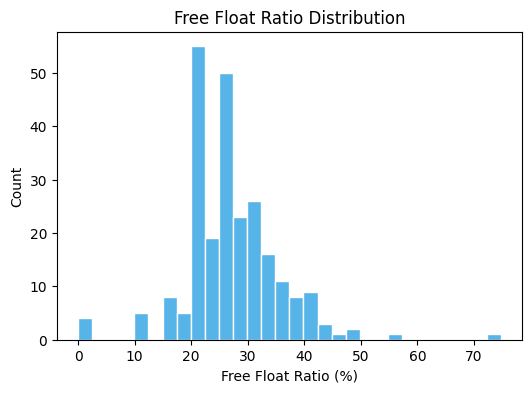

In [253]:
# Distibuion of free float ratios
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(ipo['Halka Arz Oranı (%)'].dropna(), bins=30, color='#56B4E9', edgecolor='white')
ax.set_xlabel('Free Float Ratio (%)')
ax.set_ylabel('Count')
ax.set_title('Free Float Ratio Distribution')
plt.show()

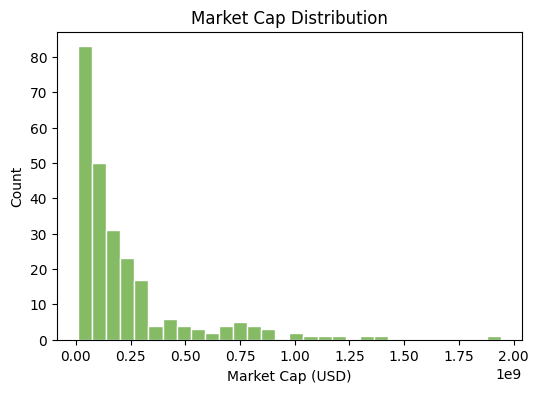

In [254]:
# Distibuion of market caps
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(ipo['market_cap_usd'].dropna(), bins=30, color='#85BB65', edgecolor='white')
ax.set_xlabel('Market Cap (USD)')
ax.set_ylabel('Count')
ax.set_title('Market Cap Distribution')
plt.show()

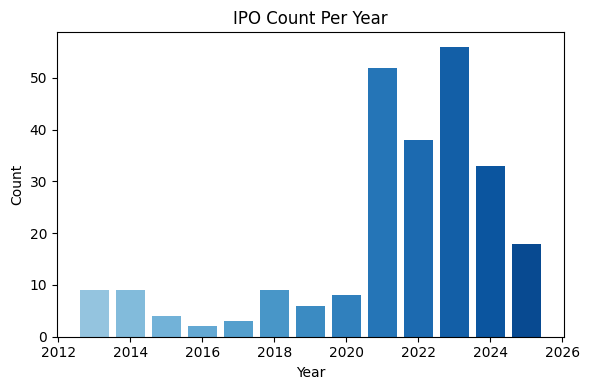

In [255]:
# IPO count by year
ipo_per_year = ipo["Year"].value_counts().sort_index() # count each year and sort by year order

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(ipo_per_year.index, ipo_per_year.values, color=plt.cm.Blues(np.linspace(0.4, 0.9, len(ipo_per_year))))
ax.set_ylabel('Count')
ax.set_xlabel('Year')
ax.set_title('IPO Count Per Year')

plt.tight_layout()
plt.show()




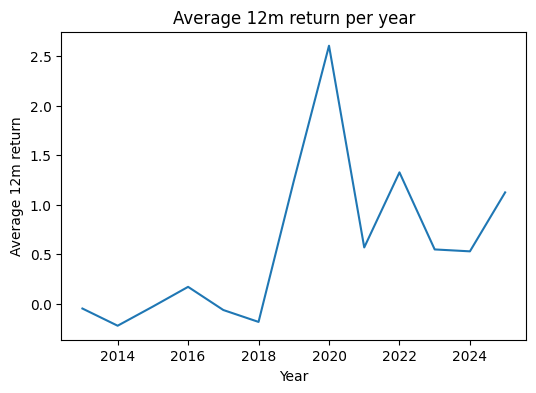

In [256]:
# Average 12m returns by year
avg_12m_return_by_year = (
    ipo.dropna(subset=['Year', 'return_12m_usd'])
    .groupby('Year')['return_12m_usd']
    .mean()
    .sort_index()
)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(avg_12m_return_by_year.index.astype(int), avg_12m_return_by_year.values)
ax.set_xlabel('Year')
ax.set_ylabel('Average 12m return')
ax.set_title('Average 12m return per year')
plt.show()

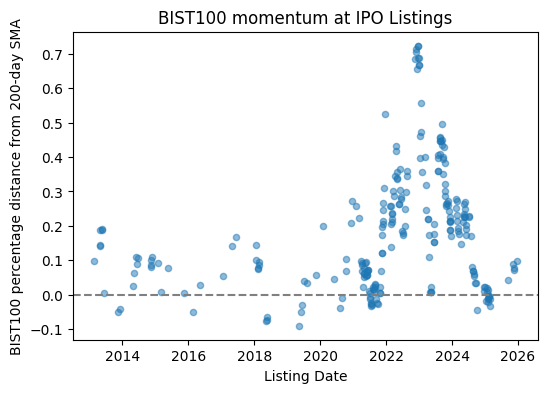

In [257]:
# IPO dates vs. Bist100 percentage distance from 200ma (Momentum)


fig, ax = plt.subplots(figsize=(6, 4))
scatter = ax.scatter(ipo['Borsada İşlem Görme Tarihi'], ipo['BIST100_SMA200_pct'], alpha=0.5, s=20,)


ax.set_xlabel('Listing Date')
ax.set_ylabel('BIST100 percentage distance from 200-day SMA')
ax.set_title('BIST100 momentum at IPO Listings')
ax.axhline(y=0, color='gray', linestyle='--')
plt.show()



## Hypothesis Testing
1. Companies with lower free float ratio perform better
2. Underwriter identity affects returns
3. Higher Relative Oversubscription (compared to IPOs around that time period) increases returns
4. REIT (GYO) Sector stocks underperform
5. IPOs listed when BIST100 momentum is high perform better
6. Lower market cap results in higher returns
7. Lower free float value results in higher returns
8. More days of consecutive 10% gain results in better returns (long term >= 12 months)

### 1. Companies with lower free float ratio perform better

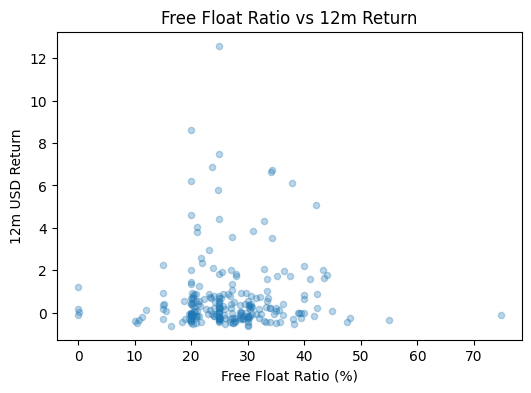

In [258]:
# Do companies with lower free float ratio perform better?
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(ipo['Halka Arz Oranı (%)'],ipo['return_12m_usd'], alpha = 0.3, s=20)
ax.set_xlabel('Free Float Ratio (%)')
ax.set_ylabel('12m USD Return')
ax.set_title('Free Float Ratio vs 12m Return')
plt.show()

In [259]:
# Use Spearman correlation since data is skewed
from scipy import stats

data = ipo[['Halka Arz Oranı (%)','return_12m_usd']].dropna()
corr, pvalue = stats.spearmanr(data['Halka Arz Oranı (%)'], data['return_12m_usd'])
print(f"Spearman correlation: {corr:.4f}")
print(f"P-value: {pvalue:.4f}")

if pvalue < 0.05:
  print("Reject the null hypothesis")
else:
  print("Fail to reject the null hypothesis")


Spearman correlation: 0.0376
P-value: 0.5634
Fail to reject the null hypothesis


### 2. Underwriter identity affects returns

In [260]:
# Kruskal Wallis since many groups and skewed

counts = ipo["Halka Arza Aracılık Eden Kurum"].value_counts()
top_underwriters = counts[counts >= 5].index
data = ipo[ipo['Halka Arza Aracılık Eden Kurum'].isin(top_underwriters)].dropna(subset=['return_12m_usd'])

groups = [group['return_12m_usd'].values for name, group in data.groupby('Halka Arza Aracılık Eden Kurum')]
stat, pvalue = stats.kruskal(*groups)
print(f"Kruskal-Wallis statistic: {stat:.4f}")
print(f"P-value: {pvalue:.4f}")

if pvalue < 0.05:
  print("Reject the null hypothesis")
else:
  print("Fail to reject the null hypothesis")


Kruskal-Wallis statistic: 30.2935
P-value: 0.0070
Reject the null hypothesis


### 3. Higher Relative Oversubscription (compared to IPOs around that time period) increases returns

In [261]:
overs = pd.read_csv('ipo_overs_cleaned.csv')
overs['Borsada İşlem Görme Tarihi'] = pd.to_datetime(overs['Borsada İşlem Görme Tarihi'])

overs_with_returns = overs.merge(
    ipo[['Borsada İşlem Görme Tarihi', 'return_12m_usd']],
    on='Borsada İşlem Görme Tarihi',
    how='inner'
).drop_duplicates(subset=['Şirket Adı'])

data = overs_with_returns[['Talebin Halka Arza Oranı', 'return_12m_usd']].dropna()
print(f"Sample size: {len(data)}")

corr, pvalue = stats.spearmanr(data['Talebin Halka Arza Oranı'], data['return_12m_usd'])
print(f"Spearman correlation: {corr:.4f}")
print(f"P value: {pvalue:.6f}")

if pvalue < 0.05:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

Sample size: 117
Spearman correlation: 0.1335
P value: 0.151225
Fail to reject the null hypothesis


### 4. REIT (GYO) Sector stocks underperform

In [262]:
# Mann-Whitney U since two groups and skewed

gyo = ipo[ipo['Sektör'].str.contains('GAYRİMENKUL YATIRIM', na=False)]['return_12m_usd'].dropna()
non_gyo = ipo[~ipo['Sektör'].str.contains('GAYRİMENKUL YATIRIM', na=False)]['return_12m_usd'].dropna()

print(f"GYO count: {len(gyo)}, Non-GYO count: {len(non_gyo)}")
stat, pvalue = stats.mannwhitneyu(gyo, non_gyo, alternative='less')
print(f"Mann-Whitney U statistic: {stat:.4f}")
print(f"P-value: {pvalue:.4f}")

if pvalue < 0.05:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

GYO count: 24, Non-GYO count: 215
Mann-Whitney U statistic: 1802.0000
P-value: 0.0078
Reject the null hypothesis


### 5. IPOs listed when BIST100 momentum is high perform better


In [263]:
# Mann-Whitney U since two groups and skewed

bull = ipo[ipo['BIST100_above_SMA200']==True]['return_12m_usd'].dropna()
bear = ipo[ipo['BIST100_above_SMA200']==False]['return_12m_usd'].dropna()

stat, pvalue = stats.mannwhitneyu(bull, bear, alternative='greater')
print(f"Mann-Whitney U statistic: {stat:.4f}")
print(f"P-value: {pvalue:.4f}")

if pvalue < 0.05:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

Mann-Whitney U statistic: 2972.0000
P-value: 0.6779
Fail to reject the null hypothesis


### 6. Lower market cap results in higher returns


In [264]:
# Use Spearman correlation since data is skewed

data = ipo[['market_cap_usd','return_12m_usd']].dropna()
corr, pvalue = stats.spearmanr(data['market_cap_usd'], data['return_12m_usd'])
print(f"Spearman correlation: {corr:.4f}")
print(f"P value: {pvalue:.5f}")

if pvalue < 0.05:
  print("Reject the null hypothesis")
else:
  print("Fail to reject the null hypothesis")

Spearman correlation: -0.2813
P value: 0.00001
Reject the null hypothesis


### 7. Lower free float value results in higher returns


In [265]:
# Use Spearman correlation since data is skewed

ipo['free_float_value_usd'] = ipo['market_cap_usd'] * (ipo['Halka Arz Oranı (%)']/100)
data = ipo[['free_float_value_usd','return_12m_usd']].dropna()
corr, pvalue = stats.spearmanr(data['free_float_value_usd'], data['return_12m_usd'])
print(f"Spearman correlation: {corr:.4f}")
print(f"P value: {pvalue:.6f}")

if pvalue < 0.05:
  print("Reject the null hypothesis")
else:
  print("Fail to reject the null hypothesis")

Spearman correlation: -0.3051
P value: 0.000002
Reject the null hypothesis


### 8. More days of consecutive 10% gain results in better returns (long term >= 12 months)

In [266]:
# Use Spearman correlation since data is skewed, use 24m

data = ipo[['tavan_days','return_24m_usd']].dropna()
corr, pvalue = stats.spearmanr(data['tavan_days'], data['return_24m_usd'])
print(f"Spearman correlation: {corr:.4f}")
print(f"P value: {pvalue:.6f}")

if pvalue < 0.05:
  print("Reject the null hypothesis")
else:
  print("Fail to reject the null hypothesis")

Spearman correlation: 0.2434
P value: 0.000481
Reject the null hypothesis


###